# 01. Linear regression, derived

**What this notebook does:** writes down the linear regression model as math, names every symbol,
derives how the best coefficients are found (two ways), and then implements each line of the math
in numpy. At the end the hand-built version is checked against scikit-learn on real data.

The math and the code are the same object in two notations. Every variable in the code is
named after the symbol it represents.

## The notation used in every notebook in this folder

| symbol | code name | what it is |
|---|---|---|
| $n$ | `n_rows` | number of rows (observations, providers, patients) |
| $p$ | `n_features` | number of features (columns of $X$) |
| $X$ | `X` | the feature matrix, shape $n \times p$. Row $i$ is one observation, column $j$ is one feature |
| $x_i$ | `X[i]` | the $i$-th row of $X$: one observation's features as a vector of length $p$ |
| $y$ | `y` | the target vector, length $n$. What we are trying to predict |
| $\hat{y}$ | `y_hat` | "y hat": the model's **prediction** of $y$. Same length as $y$ |
| $w$ | `w` | the weight (coefficient) vector, length $p$. One number per feature |
| $b$ | `b` | the bias (intercept): the prediction when every feature is zero |
| $L$ | `loss` | the loss: one number measuring how wrong $\hat{y}$ is overall |
| $\nabla_w L$ | `grad_w` | the gradient of the loss with respect to $w$: which way to move $w$ to make $L$ bigger |
| $\eta$ | `learning_rate` | "eta": step size in gradient descent |

Hats always mean "estimate." $\hat{y}$ is the estimate of $y$, $\hat{w}$ is the estimate of the true $w$.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = "C:/Users/palla/OneDrive/Documents/Coding Projects/cheatsheets_and_templates/ML_derivations/data/ml_derivations.sqlite"
con = sqlite3.connect(DB)
def q(sql):
    """Run SQL against the project database and return a DataFrame."""
    return pd.read_sql(sql, con)

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a94"

## 1. The model

Linear regression says the target is a weighted sum of the features plus a constant:

$$\hat{y}_i = w_1 x_{i1} + w_2 x_{i2} + \cdots + w_p x_{ip} + b = x_i \cdot w + b$$

For all $n$ rows at once, using matrix multiplication:

$$\hat{y} = Xw + b$$

- $Xw$ multiplies the $n \times p$ matrix by the length-$p$ vector and gives a length-$n$ vector: one prediction per row.
- $+ b$ adds the same intercept to every row.

Each weight $w_j$ answers "if feature $j$ goes up by one unit and nothing else changes, how much does the prediction change?"

**What this cell does:** builds a small synthetic dataset where the true weights are known
(so we can check the derivation recovers them), and writes the model as a function.

In [2]:
# Synthetic data with KNOWN true weights, so every method below can be checked against the truth.
n_rows, n_features = 200, 3
true_w = np.array([2.0, -1.0, 0.5])      # the weights we hope to recover
true_b = 4.0                             # the intercept we hope to recover

X = rng.normal(size=(n_rows, n_features))                  # n x p feature matrix
noise = rng.normal(scale=0.5, size=n_rows)                 # measurement noise, so the fit is not perfect
y = X @ true_w + true_b + noise                            # the target: X w + b + noise

def predict(X, w, b):
    """y_hat = X w + b.  The @ operator is matrix multiplication."""
    return X @ w + b

print("X shape:", X.shape, "  y shape:", y.shape)
print("first row x_0:", X[0].round(3), "  y_0:", round(y[0], 3))

X shape: (200, 3)   y shape: (200,)
first row x_0: [ 0.305 -1.04   0.75 ]   y_0: 6.282


## 2. The loss: how wrong is a given $w, b$?

For each row the **residual** is the miss: $e_i = y_i - \hat{y}_i$. Positive means the model
predicted too low.

The **mean squared error** squares every miss (so negatives do not cancel positives, and big
misses count more), then averages:

$$L(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2 = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - x_i \cdot w - b\right)^2$$

$L$ is a function of $w$ and $b$: change the coefficients and the loss changes. "Fitting" means
finding the $w, b$ that make $L$ as small as possible.

**What this cell does:** implements the loss and evaluates it at the true weights and at a wrong guess.

In [3]:
def mean_squared_error(y, y_hat):
    """L = (1/n) * sum of (y_i - y_hat_i)^2"""
    residuals = y - y_hat
    return np.mean(residuals ** 2)

print("loss at the TRUE weights :", round(mean_squared_error(y, predict(X, true_w, true_b)), 4), " (only the noise is left)")
print("loss at a WRONG guess    :", round(mean_squared_error(y, predict(X, np.zeros(3), 0.0)), 4))

loss at the TRUE weights : 0.258  (only the noise is left)
loss at a WRONG guess    : 21.5117


## 3. Derivation 1: gradient descent

We want the $w$ that minimizes $L$. Calculus says: at the minimum, the slope of $L$ in every
direction is zero. The **gradient** $\nabla_w L$ is the vector of those slopes, one per weight.

Take the derivative of the loss with respect to one weight $w_j$. Using the chain rule on
$(y_i - x_i \cdot w - b)^2$:

$$\frac{\partial L}{\partial w_j} = \frac{1}{n}\sum_{i=1}^{n} 2\,(y_i - \hat{y}_i)\cdot(-x_{ij}) = -\frac{2}{n}\sum_{i=1}^{n} x_{ij}\,(y_i - \hat{y}_i)$$

In words: the slope for weight $j$ is minus two times the average of (feature $j$) times (residual).
If a feature is large exactly when the residual is positive, the model is underpredicting
where that feature is big, so increasing $w_j$ would help, and the gradient is negative.

All $p$ slopes at once, as a matrix product (this is the form the code uses):

$$\nabla_w L = -\frac{2}{n} X^{\top}(y - \hat{y}) \qquad\qquad \frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)$$

$X^{\top}$ is $X$ transposed ($p \times n$), so $X^{\top}(y - \hat{y})$ is length $p$: one number per weight.

**Gradient descent** starts anywhere and repeatedly steps downhill:

$$w \leftarrow w - \eta\,\nabla_w L \qquad b \leftarrow b - \eta\,\frac{\partial L}{\partial b}$$

**What this cell does:** implements the gradient exactly as written, checks it numerically by
nudging one weight, then runs the descent loop and watches the loss fall.

slope for w_0:  numerical -1.90444   derived -1.90444

after 300 steps:  w = [ 2.018 -1.004  0.474]   b = 3.981
truth:              w = [ 2.  -1.   0.5]   b = 4.0


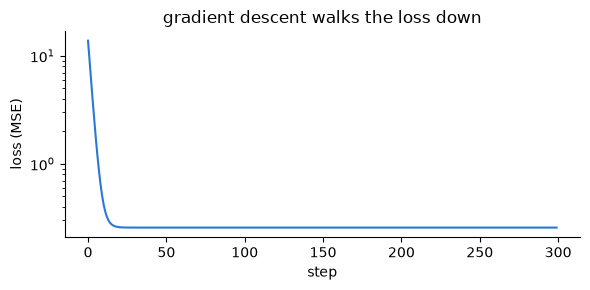

In [4]:
def gradients(X, y, w, b):
    """Returns (grad_w, grad_b) exactly as derived above."""
    n_rows = len(y)
    residuals = y - predict(X, w, b)                 # y - y_hat, length n
    grad_w = -(2.0 / n_rows) * (X.T @ residuals)      # -(2/n) X^T (y - y_hat), length p
    grad_b = -(2.0 / n_rows) * np.sum(residuals)      # -(2/n) sum(y - y_hat), a scalar
    return grad_w, grad_b

# Numerical check: nudge w_0 by a tiny amount and see how much the loss changes.
# The ratio (change in loss / nudge) should equal the derived gradient for w_0.
w_test, b_test, nudge = np.array([1.0, 1.0, 1.0]), 0.0, 1e-6
loss_before = mean_squared_error(y, predict(X, w_test, b_test))
w_nudged = w_test.copy(); w_nudged[0] += nudge
loss_after = mean_squared_error(y, predict(X, w_nudged, b_test))
numerical_slope = (loss_after - loss_before) / nudge
derived_slope = gradients(X, y, w_test, b_test)[0][0]
print(f"slope for w_0:  numerical {numerical_slope:.5f}   derived {derived_slope:.5f}")

# Gradient descent.
w, b = np.zeros(n_features), 0.0           # start from nothing
learning_rate, n_steps = 0.1, 300
loss_history = []
for step in range(n_steps):
    grad_w, grad_b = gradients(X, y, w, b)
    w = w - learning_rate * grad_w           # step downhill
    b = b - learning_rate * grad_b
    loss_history.append(mean_squared_error(y, predict(X, w, b)))

print(f"\nafter {n_steps} steps:  w = {w.round(3)}   b = {b:.3f}")
print(f"truth:              w = {true_w}   b = {true_b}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(loss_history, color=BLUE)
ax.set(xlabel="step", ylabel="loss (MSE)", title="gradient descent walks the loss down", yscale="log")
plt.tight_layout(); plt.show()

## 4. Derivation 2: the closed form (normal equation)

For linear regression specifically, we do not have to search. Set the gradient to zero and solve.

First fold the intercept into the weights by adding a column of ones to $X$. Call that
$\tilde{X}$ ($n \times (p+1)$) and the extended weight vector $\tilde{w} = (b, w_1, \ldots, w_p)$.
Then $\hat{y} = \tilde{X}\tilde{w}$ and the gradient is $-\frac{2}{n}\tilde{X}^{\top}(y - \tilde{X}\tilde{w})$.

Set it to zero and rearrange:

$$\tilde{X}^{\top}(y - \tilde{X}\tilde{w}) = 0
\quad\Rightarrow\quad
\tilde{X}^{\top}\tilde{X}\,\tilde{w} = \tilde{X}^{\top}y
\quad\Rightarrow\quad
\boxed{\hat{\tilde{w}} = (\tilde{X}^{\top}\tilde{X})^{-1}\tilde{X}^{\top}y}$$

This is the **normal equation**. One matrix inversion, no iterations, exact answer. It is what
`LinearRegression` does (via a numerically safer equivalent). It fails when
$\tilde{X}^{\top}\tilde{X}$ cannot be inverted, which happens with perfectly correlated features
or more features than rows. Ridge regression (notebook 03) fixes exactly that.

**What this cell does:** builds $\tilde{X}$, applies the formula, and compares to gradient descent and to the truth.

In [5]:
X_with_ones = np.column_stack([np.ones(n_rows), X])          # X tilde: first column is all ones (for b)

w_closed_form = np.linalg.solve(X_with_ones.T @ X_with_ones, X_with_ones.T @ y)
# np.linalg.solve(A, c) finds the vector v with A v = c. Same as inv(A) @ c, but more accurate.

b_closed, w_closed = w_closed_form[0], w_closed_form[1:]
print(f"closed form:      w = {w_closed.round(3)}   b = {b_closed:.3f}")
print(f"gradient descent: w = {w.round(3)}   b = {b:.3f}")
print(f"truth:            w = {true_w}   b = {true_b}")

closed form:      w = [ 2.018 -1.004  0.474]   b = 3.981
gradient descent: w = [ 2.018 -1.004  0.474]   b = 3.981
truth:            w = [ 2.  -1.   0.5]   b = 4.0


## 5. R-squared: how much of the variation did we explain?

Compare the model's error to the dumbest model, which predicts the mean $\bar{y}$ for everyone:

$$SS_{\text{res}} = \sum_i (y_i - \hat{y}_i)^2 \qquad SS_{\text{tot}} = \sum_i (y_i - \bar{y})^2 \qquad R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

$R^2 = 1$ means no error. $R^2 = 0$ means no better than the mean. Negative means worse than the mean,
which can happen on held-out data.

In [6]:
def r_squared(y, y_hat):
    sum_squares_residual = np.sum((y - y_hat) ** 2)
    sum_squares_total = np.sum((y - y.mean()) ** 2)
    return 1 - sum_squares_residual / sum_squares_total

print("R^2 of the closed-form fit:", round(r_squared(y, predict(X, w_closed, b_closed)), 4))

R^2 of the closed-form fit: 0.9499


## 6. Check against scikit-learn on real data

**What this cell does:** pulls the California housing table, splits it, fits the closed form by hand
and `LinearRegression` from the library, and confirms the coefficients and test $R^2$ match.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

housing = q("SELECT * FROM housing")
feature_names = [c for c in housing.columns if c != "median_house_value"]
X_real = housing[feature_names].to_numpy()
y_real = housing["median_house_value"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=SEED)

# By hand: normal equation on the training set.
X_train_ones = np.column_stack([np.ones(len(X_train)), X_train])
w_hand = np.linalg.solve(X_train_ones.T @ X_train_ones, X_train_ones.T @ y_train)
y_hat_test_hand = np.column_stack([np.ones(len(X_test)), X_test]) @ w_hand

# Library.
library_model = LinearRegression().fit(X_train, y_train)
y_hat_test_library = library_model.predict(X_test)

comparison = pd.DataFrame({"by_hand": w_hand[1:], "sklearn": library_model.coef_}, index=feature_names)
print(comparison.round(5))
print(f"\nintercept  by hand {w_hand[0]:.5f}   sklearn {library_model.intercept_:.5f}")
print(f"test R^2   by hand {r_squared(y_test, y_hat_test_hand):.5f}   sklearn {library_model.score(X_test, y_test):.5f}")

            by_hand  sklearn
medinc      0.44867  0.44867
houseage    0.00972  0.00972
averooms   -0.12332 -0.12332
avebedrms   0.78314  0.78314
population -0.00000 -0.00000
aveoccup   -0.00353 -0.00353
latitude   -0.41979 -0.41979
longitude  -0.43371 -0.43371

intercept  by hand -37.02328   sklearn -37.02328
test R^2   by hand 0.57579   sklearn 0.57579


## Summary

- **Model:** $\hat{y} = Xw + b$. One weight per feature, read as "effect of a one-unit change."
- **Loss:** mean squared error, a function of $w$ and $b$.
- **Fit, two ways:** step downhill along $-\nabla_w L = \frac{2}{n}X^{\top}(y - \hat{y})$, or solve
  $\hat{w} = (X^{\top}X)^{-1}X^{\top}y$ in one shot.
- **Everything else in this folder is a variation on these three pieces:** change the model
  (logistic), change the loss (log loss), add a term to the loss (regularization), or replace
  the linear model with trees and fit the residuals (boosting).

In [8]:
con.close()